# TimeSformer MAE Training

Train TimeSformer encoder with VideoMAE (masked autoencoding) pretraining.

## Setup

In [1]:
import os
import sys
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
import time
from datetime import datetime

from config import get_mae_config, get_small_config
from timesformer_mae import TimeSformerMAE
from dataset import create_dataloaders

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

GPU: NVIDIA GeForce RTX 5060 Laptop GPU


## Configuration

In [2]:
DATA_ROOT = r"C:\\Users\\shrua\\OneDrive\\Desktop\\threshold project\\threshold\\data"

MODEL_SIZE = 'default'  # Change to 'default' for full training

# Training hyperparameters
NUM_EPOCHS = 10  # Start with 5 for testing, use 100+ for full training
BATCH_SIZE = 4
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.05
TRAIN_SPLIT = 0.85

NUM_WORKERS = 0
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

OUTPUT_DIR = r"C:\\Users\\shrua\\OneDrive\\Desktop\\threshold project\\threshold\\models\\output"
SAVE_FREQ = 5  # Save checkpoint every N epochs

print("Configuration:")
print(f"  Model size: {MODEL_SIZE}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Device: {DEVICE}")
print(f"  Output: {OUTPUT_DIR}")

Configuration:
  Model size: default
  Epochs: 10
  Batch size: 4
  Device: cuda
  Output: C:\\Users\\shrua\\OneDrive\\Desktop\\threshold project\\threshold\\models\\output


In [3]:
# Create output directories
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, 'checkpoints'), exist_ok=True)
print(f"✓ Output directories created")

✓ Output directories created


## Load Data

In [4]:
print("Loading dataset...")

train_loader, val_loader = create_dataloaders(
    data_root=DATA_ROOT,
    batch_size=BATCH_SIZE,
    train_split=TRAIN_SPLIT,
    num_workers=NUM_WORKERS,
)

print(f"✓ Data loaded")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Train samples: {len(train_loader.dataset)}")
print(f"  Val samples: {len(val_loader.dataset)}")

Loading dataset...
Found 8 threshold CSV files
Loaded 1835 threshold sequences from 8 files
Train size: 1559, Val size: 276
✓ Data loaded
  Train batches: 390
  Val batches: 69
  Train samples: 1559
  Val samples: 276


## Create Model

In [5]:
# Get config
if MODEL_SIZE == 'small':
    config = get_small_config()
    print("Using SMALL model (for testing)")
else:
    config = get_mae_config()
    print("Using DEFAULT model (for training)")

# Create model
model = TimeSformerMAE(config)
model = model.to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n✓ Model created")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Encoder parameters: {sum(p.numel() for p in model.encoder.parameters()):,}")
print(f"  Decoder parameters: {sum(p.numel() for p in model.decoder.parameters()):,}")

Configuration:
  Image size: 32x64
  Patch size: 4x4
  Patches per frame: 128 (8x16)
  Total frames: 7
  Total patches: 896
  Visible patches (~10%): ~89
  Masked patches (~90%): ~806
Using DEFAULT model (for training)

✓ Model created
  Total parameters: 16,594,800
  Trainable parameters: 16,594,800
  Encoder parameters: 14,559,360
  Decoder parameters: 2,035,056


## Setup Training

In [6]:
# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.95),
)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=LEARNING_RATE * 0.01,
)

print("✓ Optimizer and scheduler created")

✓ Optimizer and scheduler created


In [7]:
# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'learning_rate': [],
    'epoch_time': [],
}

best_val_loss = float('inf')

## Training Functions

In [8]:
def train_one_epoch(model, dataloader, optimizer, device, epoch):
    """
    Train for one epoch.
    """
    model.train()
    total_loss = 0
    
    pbar = tqdm(dataloader, desc=f"Epoch {epoch} [Train]")
    
    for batch in pbar:
        pixel_values = batch['pixel_values'].to(device)
        
        # Forward pass
        loss, pred, mask = model(pixel_values)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Accumulate loss
        total_loss += loss.item()
        
        # Update progress bar
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(dataloader)
    return avg_loss


def validate(model, dataloader, device, epoch):
    """
    Validate the model.
    """
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc=f"Epoch {epoch} [Val]")
        
        for batch in pbar:
            pixel_values = batch['pixel_values'].to(device)
            
            loss, pred, mask = model(pixel_values)
            
            total_loss += loss.item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(dataloader)
    return avg_loss


def save_checkpoint(model, optimizer, epoch, loss, filename):
    """
    Save model checkpoint.
    """
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }
    torch.save(checkpoint, filename)
    print(f"  💾 Saved: {os.path.basename(filename)}")


print("✓ Training functions defined")

✓ Training functions defined


## TRAINING

In [9]:
RESUME_TRAINING = False  # Set to True to resume from checkpoint
CHECKPOINT_TO_RESUME = os.path.join(OUTPUT_DIR, 'checkpoints', 'best_model.pt')
# Or use: 'checkpoint_epoch_0004.pt' for specific epoch

if RESUME_TRAINING and os.path.exists(CHECKPOINT_TO_RESUME):
    print("="*80)
    print("RESUMING FROM CHECKPOINT")
    print("="*80)
    
    # Load checkpoint
    checkpoint = torch.load(CHECKPOINT_TO_RESUME, map_location=DEVICE)
    
    # Load model state
    model.load_state_dict(checkpoint['model_state_dict'])
    
    # Load optimizer state
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
    # Get starting epoch
    start_epoch = checkpoint['epoch'] + 1  # Start from next epoch
    previous_loss = checkpoint.get('loss', 'unknown')
    
    print(f"✓ Loaded checkpoint from epoch {checkpoint['epoch']}")
    print(f"  Previous loss: {previous_loss}")
    print(f"  Resuming from epoch {start_epoch}")
    print(f"  Will train for {NUM_EPOCHS - start_epoch} more epochs")
    print("="*80 + "\n")
    
    # NOTE: If you want to preserve previous history, load it too
    # You'd need to save history in your checkpoint for this
    
else:
    start_epoch = 0
    print("Starting training from scratch (epoch 0)\n")

Starting training from scratch (epoch 0)



In [10]:
print("="*80)
print(f"STARTING TRAINING: {NUM_EPOCHS} epochs")
print("="*80)
print(f"Start time: {datetime.now().strftime('%H:%M:%S')}")
print()

for epoch in range(start_epoch, NUM_EPOCHS):
    epoch_start = time.time()
    
    # Train
    train_loss = train_one_epoch(model, train_loader, optimizer, DEVICE, epoch)
    
    # Validate
    val_loss = validate(model, val_loader, DEVICE, epoch)
    
    # Update scheduler
    scheduler.step()
    
    # Record history
    epoch_time = time.time() - epoch_start
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['learning_rate'].append(optimizer.param_groups[0]['lr'])
    history['epoch_time'].append(epoch_time)
    
    # Print epoch summary
    print(f"\nEpoch {epoch}/{NUM_EPOCHS-1}")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}")
    print(f"  LR:         {optimizer.param_groups[0]['lr']:.6f}")
    print(f"  Time:       {epoch_time:.1f}s")
    
    # Save checkpoint
    if (epoch + 1) % SAVE_FREQ == 0:
        checkpoint_path = os.path.join(
            OUTPUT_DIR, 'checkpoints', f'checkpoint_epoch_{epoch:04d}.pt'
        )
        save_checkpoint(model, optimizer, epoch, val_loss, checkpoint_path)
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_path = os.path.join(OUTPUT_DIR, 'checkpoints', 'best_model.pt')
        save_checkpoint(model, optimizer, epoch, val_loss, best_path)
        print(f"  New best model! (val_loss: {val_loss:.4f})")
    
    print("-" * 80)

print("\n" + "="*80)
print("TRAINING COMPLETE!")
print("="*80)
print(f"End time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Total time: {sum(history['epoch_time'])/60:.1f} minutes")

STARTING TRAINING: 10 epochs
Start time: 11:34:04



Epoch 0 [Train]:   0%|          | 0/390 [00:00<?, ?it/s]

Epoch 0 [Val]:   0%|          | 0/69 [00:00<?, ?it/s]


Epoch 0/9
  Train Loss: 0.6088
  Val Loss:   0.4451
  LR:         0.000098
  Time:       52.7s
  💾 Saved: best_model.pt
  New best model! (val_loss: 0.4451)
--------------------------------------------------------------------------------


Epoch 1 [Train]:   0%|          | 0/390 [00:00<?, ?it/s]

...

Epoch 8 [Val]:   0%|          | 0/69 [00:00<?, ?it/s]


Epoch 8/9
  Train Loss: 0.1815
  Val Loss:   0.1650
  LR:         0.000003
  Time:       51.2s
  💾 Saved: best_model.pt
  New best model! (val_loss: 0.1650)
--------------------------------------------------------------------------------


Epoch 9 [Train]:   0%|          | 0/390 [00:00<?, ?it/s]

Epoch 9 [Val]:   0%|          | 0/69 [00:00<?, ?it/s]


Epoch 9/9
  Train Loss: 0.1782
  Val Loss:   0.1639
  LR:         0.000001
  Time:       52.3s
  💾 Saved: checkpoint_epoch_0009.pt
  💾 Saved: best_model.pt
  New best model! (val_loss: 0.1639)
--------------------------------------------------------------------------------

TRAINING COMPLETE!
End time: 2025-11-09 11:42:09
Best validation loss: 0.1639
Total time: 8.0 minutes


## Save Final Model

In [ ]:
# Save final model
final_path = os.path.join(OUTPUT_DIR, 'checkpoints', 'final_model.pt')
save_checkpoint(model, optimizer, NUM_EPOCHS - 1, history['val_loss'][-1], final_path)

# Save encoder only (for classification fine-tuning)
encoder_path = os.path.join(OUTPUT_DIR, 'timesformer_encoder_pretrained.pt')
torch.save({
    'config': config,
    'encoder_state_dict': model.encoder.state_dict(),
}, encoder_path)

print(f"\n✓ Pretrained encoder saved: {encoder_path}")
print("\n⭐ Use this encoder for classification fine-tuning (next step)")

## Visualize Training Results

Loading BEST model for visualization...
✓ Loaded best model from epoch 9
  Loss: 0.1639



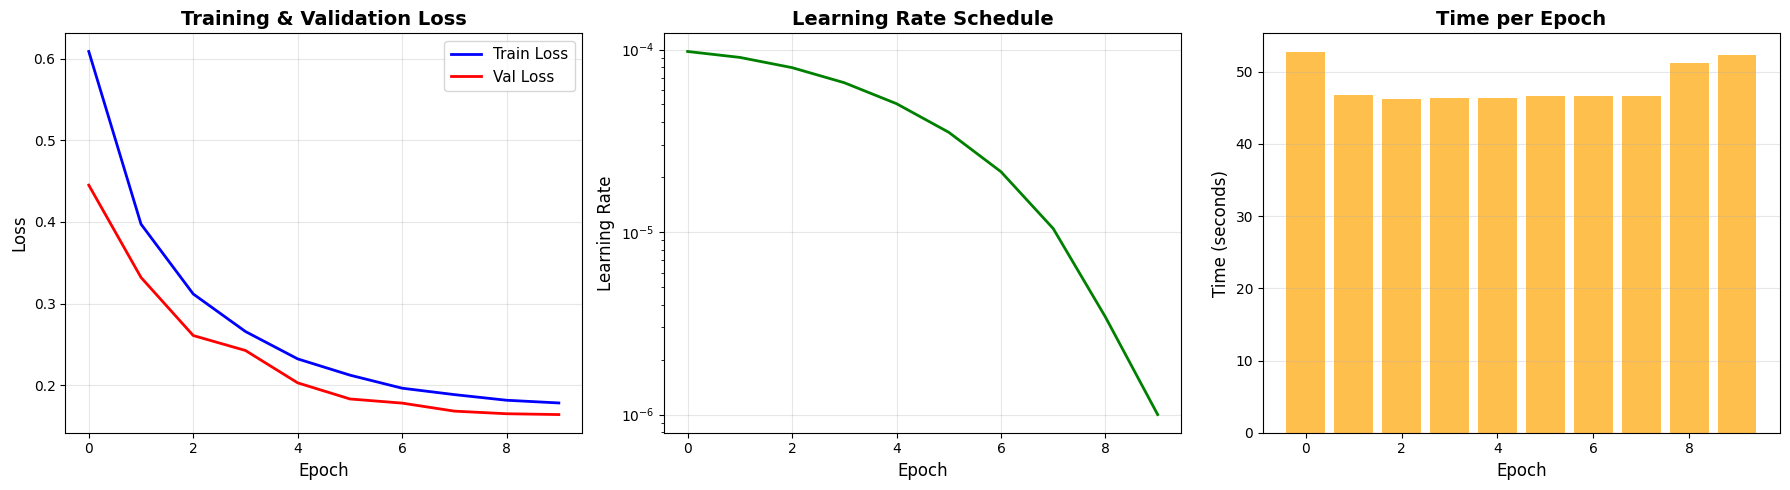


✓ Training curves saved to: C:\\Users\\shrua\\OneDrive\\Desktop\\threshold project\\threshold\\models\\output\training_curves.png


In [11]:
print("Loading BEST model for visualization...")

# Path to best checkpoint
BEST_CHECKPOINT = os.path.join(OUTPUT_DIR, 'checkpoints', 'best_model.pt')

# Load checkpoint
checkpoint = torch.load(BEST_CHECKPOINT, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(DEVICE)
model.eval()

print(f"✓ Loaded best model from epoch {checkpoint['epoch']}")
print(f"  Loss: {checkpoint['loss']:.4f}")
print()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Loss curves
epochs_range = range(len(history['train_loss']))
axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: Learning rate
axes[1].plot(epochs_range, history['learning_rate'], 'g-', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Learning Rate', fontsize=12)
axes[1].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')

# Plot 3: Time per epoch
axes[2].bar(epochs_range, history['epoch_time'], color='orange', alpha=0.7)
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Time (seconds)', fontsize=12)
axes[2].set_title('Time per Epoch', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Training curves saved to: {os.path.join(OUTPUT_DIR, 'training_curves.png')}")

  0%|          | 0/69 [00:00<?, ?it/s]

Extracted 276 embeddings
Computing t-SNE...
Computing k-means...


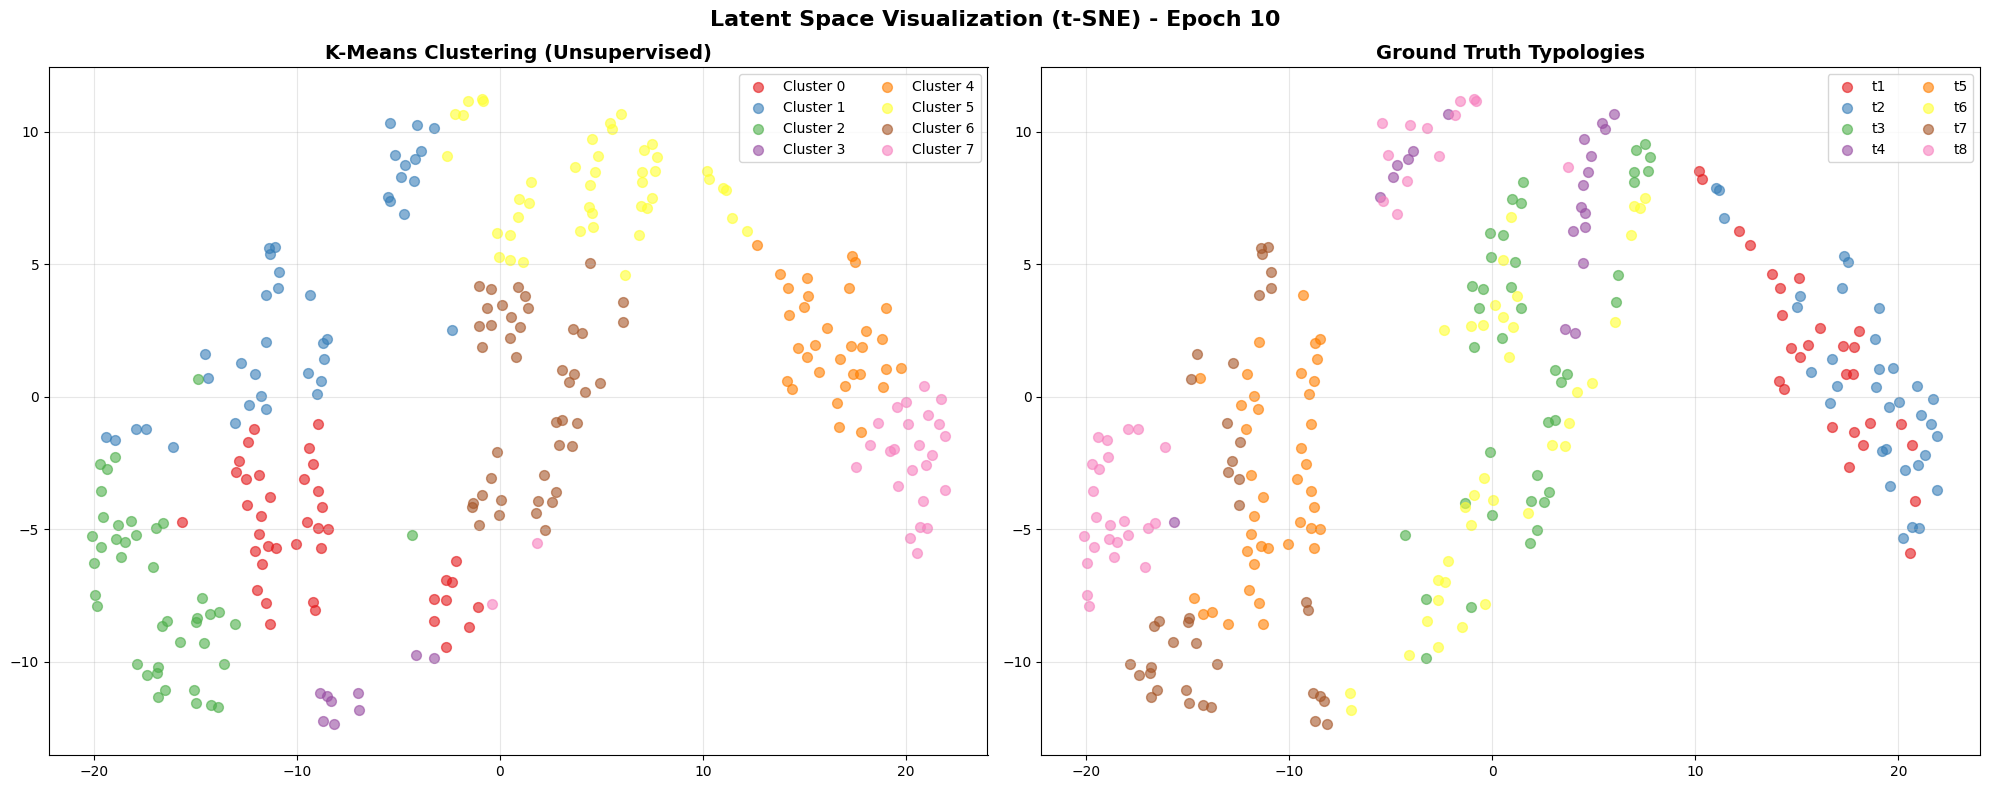


Cluster analysis:
  Cluster 0:  40 samples, dominant=t5, purity=57.5%
  Cluster 1:  40 samples, dominant=t5, purity=32.5%
  Cluster 2:  42 samples, dominant=t8, purity=45.2%
  Cluster 3:   9 samples, dominant=t7, purity=55.6%
  Cluster 4:  32 samples, dominant=t1, purity=56.2%
  Cluster 5:  44 samples, dominant=t3, purity=31.8%
  Cluster 6:  43 samples, dominant=t3, purity=48.8%
  Cluster 7:  26 samples, dominant=t2, purity=65.4%


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from tqdm.notebook import tqdm

# Extract embeddings from validation set
all_embeddings = []
all_labels = []

model.eval()
with torch.no_grad():
    for i, batch in enumerate(tqdm(val_loader)):
        pixel_values = batch['pixel_values'].to(DEVICE)
        labels = batch['labels'].numpy()
        
        # Get embeddings
        x = model.encoder.patch_embed(pixel_values)
        latent = model.encoder(x)
        latent_pooled = latent.mean(dim=1)  # Pool across patches
        
        all_embeddings.append(latent_pooled.cpu().numpy())
        all_labels.append(labels)

embeddings = np.concatenate(all_embeddings)
labels = np.concatenate(all_labels)

print(f"Extracted {len(embeddings)} embeddings")

# t-SNE projection
print("Computing t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
embeddings_2d = tsne.fit_transform(embeddings)

# K-means clustering
print("Computing k-means...")
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
clusters = kmeans.fit_predict(embeddings)

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', 
          '#ff7f00', '#ffff33', '#a65628', '#f781bf']

# Left: K-means clusters (unsupervised)
for i in range(8):
    mask = clusters == i
    axes[0].scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
                   c=colors[i], label=f'Cluster {i}', alpha=0.6, s=50)
axes[0].set_title('K-Means Clustering (Unsupervised)', fontsize=14, fontweight='bold')
axes[0].legend(ncol=2)
axes[0].grid(alpha=0.3)

# Right: Ground truth typologies
for i in range(8):
    mask = labels == i
    if mask.sum() > 0:
        axes[1].scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
                       c=colors[i], label=f't{i+1}', alpha=0.6, s=50)
axes[1].set_title('Ground Truth Typologies', fontsize=14, fontweight='bold')
axes[1].legend(ncol=2)
axes[1].grid(alpha=0.3)

plt.suptitle(f'Latent Space Visualization (t-SNE) - Epoch {NUM_EPOCHS}', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'tsne_clustering.png'), dpi=300, bbox_inches='tight')
plt.show()

# Compute cluster purity
print("\nCluster analysis:")
for i in range(8):
    mask = clusters == i
    cluster_types = labels[mask]
    if len(cluster_types) > 0:
        unique, counts = np.unique(cluster_types, return_counts=True)
        dominant = unique[np.argmax(counts)]
        purity = counts.max() / len(cluster_types)
        print(f"  Cluster {i}: {len(cluster_types):3d} samples, dominant=t{dominant+1}, purity={purity:.1%}")

## Training Statistics

In [11]:
print("="*80)
print("TRAINING STATISTICS")
print("="*80)
print(f"\nFinal Results:")
print(f"  Final Train Loss: {history['train_loss'][-1]:.4f}")
print(f"  Final Val Loss:   {history['val_loss'][-1]:.4f}")
print(f"  Best Val Loss:    {best_val_loss:.4f} (epoch {np.argmin(history['val_loss'])})")

print(f"\nImprovement:")
print(f"  Train Loss: {history['train_loss'][0]:.4f} → {history['train_loss'][-1]:.4f}")
print(f"  Val Loss:   {history['val_loss'][0]:.4f} → {history['val_loss'][-1]:.4f}")
print(f"  Reduction:  {(1 - history['val_loss'][-1]/history['val_loss'][0])*100:.1f}%")

print(f"\nTiming:")
print(f"  Total time:       {sum(history['epoch_time'])/60:.1f} minutes")
print(f"  Avg time/epoch:   {np.mean(history['epoch_time']):.1f} seconds")
print(f"  Est. for 100 epochs: {np.mean(history['epoch_time'])*100/3600:.1f} hours")

print(f"\nOutput Files:")
print(f"  Best model:        {os.path.join(OUTPUT_DIR, 'checkpoints', 'best_model.pt')}")
print(f"  Final model:       {os.path.join(OUTPUT_DIR, 'checkpoints', 'final_model.pt')}")
print(f"  Pretrained encoder: {os.path.join(OUTPUT_DIR, 'timesformer_encoder_pretrained.pt')}")
print("="*80)

TRAINING STATISTICS

Final Results:
  Final Train Loss: 0.1420
  Final Val Loss:   0.1193
  Best Val Loss:    0.1193 (epoch 4)

Improvement:
  Train Loss: 0.4564 → 0.1420
  Val Loss:   0.2895 → 0.1193
  Reduction:  58.8%

Timing:
  Total time:       10.9 minutes
  Avg time/epoch:   130.6 seconds
  Est. for 100 epochs: 3.6 hours

Output Files:
  Best model:        C:\\Users\\shrua\\OneDrive\\Desktop\\threshold project\\threshold\\models\\output\checkpoints\best_model.pt
  Final model:       C:\\Users\\shrua\\OneDrive\\Desktop\\threshold project\\threshold\\models\\output\checkpoints\final_model.pt
  Pretrained encoder: C:\\Users\\shrua\\OneDrive\\Desktop\\threshold project\\threshold\\models\\output\timesformer_encoder_pretrained.pt


## Next Steps

After pretraining completes:

1. **Load pretrained encoder** for classification fine-tuning
2. **Analyze attention patterns** to validate learning
3. **Visualize embeddings** to understand threshold representations

The pretrained encoder is saved in:
```
output/timesformer_encoder_pretrained.pt
```